In [23]:
import os, random
from pathlib import Path
import joblib, json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import optuna
import two_stage_model as tsm
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier, XGBRegressor

SEED = 42
MIN_OBSERVED_TARGETS = 2
GROUP_COLS = ["Primary Code"]  # grouping variables for joint covariance matrices
LOG_EPS = 1e-6             # small constant: log(y + LOG_EPS)

X_cols = ["Construction period", "Typology", "Primary Code", "Hybrid Structure", "Country"]
y_cols = ["Concrete", "Glass", "Steel", "Wood", "Brick"]

def set_global_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)

set_global_seed(SEED)
print("Imports complete. SEED =", SEED)
print("Joint covariance grouping columns:", GROUP_COLS)

Imports complete. SEED = 42
Joint covariance grouping columns: ['Primary Code']


In [24]:
# ==========================================================
# Data Preparation
# ==========================================================

def build_group_keys(df, group_cols=GROUP_COLS):
    return (
        df.loc[:, group_cols]
        .fillna("Missing")
        .astype(str)
        .agg(" | ".join, axis=1)
        .to_numpy()
    )

def prepare_data(
    file_path="Integrated_MI_database_add_Singapore.xlsx",
    test_size=0.30,
    val_size=0.50,
    clip_upper_quantile=0.99,
    clip_materials=("Steel", "Glass", "Concrete", "Brick", "Wood"),
    min_observed_targets=MIN_OBSERVED_TARGETS,
    random_state=SEED,
):
    # Load, split, and preprocess the MI database.
    # Returns numpy arrays together with raw DataFrames for group-label access.
    file_path = Path(file_path)
    if not file_path.is_absolute():
        file_path = Path.cwd() / file_path

    df = pd.read_excel(file_path)
    df["Construction period"] = pd.to_numeric(df["Construction period"], errors="coerce")
    df = df.dropna(subset=X_cols).reset_index(drop=True)

    target_mask_df = df[y_cols].notna()
    df = df.loc[target_mask_df.sum(axis=1) >= min_observed_targets].reset_index(drop=True)

    X = df[X_cols].copy()
    y_raw_df = df[y_cols].copy()
    y_mask = y_raw_df.notna().to_numpy(dtype=bool)

    X_train, X_temp, y_train_df, y_temp_df, y_train_mask, y_temp_mask = train_test_split(
        X, y_raw_df, y_mask, test_size=test_size, random_state=random_state
    )
    X_val, X_test, y_val_df, y_test_df, y_val_mask, y_test_mask = train_test_split(
        X_temp, y_temp_df, y_temp_mask, test_size=val_size, random_state=random_state
    )

    for df_ in [X_train, X_val, X_test, y_train_df, y_val_df, y_test_df]:
        df_.reset_index(drop=True, inplace=True)

    y_train_raw = y_train_df.to_numpy(dtype=np.float64)
    y_val_raw   = y_val_df.to_numpy(dtype=np.float64)
    y_test_raw  = y_test_df.to_numpy(dtype=np.float64)

    # Upper-quantile clipping on training statistics applied to all splits
    clip_bounds = None
    if clip_upper_quantile is not None:
        mat_to_idx = {m: i for i, m in enumerate(y_cols)}
        upper_bounds = {}
        for mat in clip_materials:
            if mat not in mat_to_idx:
                continue
            idx = mat_to_idx[mat]
            obs = y_train_mask[:, idx]
            if not np.any(obs):
                continue
            ub = np.quantile(y_train_raw[obs, idx], clip_upper_quantile)
            for arr, mask in [(y_train_raw, y_train_mask), (y_val_raw, y_val_mask),
                              (y_test_raw, y_test_mask)]:
                rows = mask[:, idx]
                arr[rows, idx] = np.minimum(arr[rows, idx], ub)
            upper_bounds[mat] = float(ub)
        clip_bounds = {"upper_quantile": clip_upper_quantile, "upper_bounds": upper_bounds}

    preprocessor = ColumnTransformer(transformers=[
        ("num", StandardScaler(), ["Construction period"]),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
         ["Typology", "Primary Code", "Hybrid Structure", "Country"]),
    ])
    X_train_proc = preprocessor.fit_transform(X_train)
    X_val_proc   = preprocessor.transform(X_val)
    X_test_proc  = preprocessor.transform(X_test)

    return dict(
        X_train_proc=X_train_proc, X_val_proc=X_val_proc, X_test_proc=X_test_proc,
        X_train_raw=X_train,       X_val_raw=X_val,        X_test_raw=X_test,
        y_train_raw=y_train_raw,   y_val_raw=y_val_raw,    y_test_raw=y_test_raw,
        y_train_df=y_train_df,     y_val_df=y_val_df,      y_test_df=y_test_df,
        y_train_mask=y_train_mask, y_val_mask=y_val_mask,  y_test_mask=y_test_mask,
        groups_train=build_group_keys(X_train),
        groups_val  =build_group_keys(X_val),
        groups_test =build_group_keys(X_test),
        preprocessor=preprocessor,
        clip_bounds=clip_bounds,
        kept_rows=len(df),
        min_observed_targets=min_observed_targets,
    )

In [25]:
set_global_seed(SEED)
data = prepare_data()

print("Data preparation complete.")
print(f"X_train: {data['X_train_proc'].shape}  y_train: {data['y_train_raw'].shape}")
print(f"X_val:   {data['X_val_proc'].shape}  y_val:   {data['y_val_raw'].shape}")
print(f"X_test:  {data['X_test_proc'].shape}  y_test:  {data['y_test_raw'].shape}")
print(f"Rows kept: {data['kept_rows']}  (min observed targets: {data['min_observed_targets']})")

for split in ["train", "val", "test"]:
    mask = data[f"y_{split}_mask"]
    obs  = mask.sum(axis=1)
    print(f"  {split}: obs/row  min={obs.min()}  mean={obs.mean():.2f}  max={obs.max()}")

Data preparation complete.
X_train: (1799, 47)  y_train: (1799, 5)
X_val:   (385, 47)  y_val:   (385, 5)
X_test:  (386, 47)  y_test:  (386, 5)
Rows kept: 2570  (min observed targets: 2)
  train: obs/row  min=2  mean=3.65  max=5
  val: obs/row  min=2  mean=3.57  max=5
  test: obs/row  min=2  mean=3.69  max=5


In [26]:
# ==========================================================
# Stage 1 — Material Occurrence Model  (XGBoost classifier)
#
# Predicts P(a_{i,m} = 1 | x_i) for each material m via
# a per-material XGBClassifier with binary:logistic objective.
# ==========================================================

class MaterialOccurrenceModel:
    """Classifier chain for joint material presence modeling.

    Trains one XGBClassifier per material in prevalence-descending order.
    Each classifier conditions on all previously fitted materials, capturing
    co-occurrence dependencies that independent Bernoulli sampling misses.

    fit / predict_proba keep the same signatures as before.
    calibrate()       fits per-material IsotonicRegression on a held-out set.
    sample_presence() draws coherent joint combinations via ancestral sampling,
                      applying calibration at each chain step if fitted.
    evaluate_calibration() prints reliability diagnostics and returns plot data.
    """

    def __init__(
        self,
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.0,
        reg_lambda=1.0,
        random_state=SEED,
    ):
        self.xgb_params = dict(
            n_estimators=n_estimators,
            max_depth=max_depth,
            learning_rate=learning_rate,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            reg_alpha=reg_alpha,
            reg_lambda=reg_lambda,
            random_state=random_state,
            objective="binary:logistic",
            verbosity=0,
        )
        self.models_ = {}
        self.trivial_proba_ = {}
        self.calibrators_ = {}
        self.chain_order_ = list(range(len(y_cols)))

    @staticmethod
    def _chain_X(X, ctx_cols):
        """Append accumulated chain columns to base features."""
        if not ctx_cols:
            return X
        return np.hstack([X, np.column_stack(ctx_cols)])

    def fit(self, X, y_presence):
        """Fit classifier chain in descending binary-entropy order.

        Each XGBClassifier is wrapped with CalibratedClassifierCV so that
        predict_proba() outputs calibrated probabilities directly.
        Isotonic regression is used when n_samples >= 100 (enough data for
        monotone fit); Platt scaling (sigmoid) is used otherwise.
        """
        self.models_ = {}
        self.trivial_proba_ = {}
        self.calibrators_ = {}   # reset: calibration is now baked into models_
        p = y_presence.mean(axis=0).clip(1e-9, 1 - 1e-9)
        entropy = -p * np.log(p) - (1 - p) * np.log(1 - p)
        self.chain_order_ = list(np.argsort(-entropy))
        n = X.shape[0]
        cal_method = "isotonic" if n >= 100 else "sigmoid"
        ctx = []   # list of (N,) float arrays — observed labels so far
        for m in self.chain_order_:
            material = y_cols[m]
            obs = y_presence[:, m]
            p = float(obs.mean())
            if p == 0.0 or p == 1.0:
                self.trivial_proba_[material] = p
                self.models_[material] = None
            else:
                base = XGBClassifier(**self.xgb_params)
                clf = CalibratedClassifierCV(base, method=cal_method, cv=5)
                clf.fit(self._chain_X(X, ctx), obs.astype(int))
                self.models_[material] = clf
            ctx.append(obs.astype(np.float64))
        return self

    def calibrate(self, X_val, y_val_presence):
        """Fit per-material isotonic calibrators on held-out presence labels.

        For each material in chain order, computes the raw conditional
        probability P(z_m=1 | X_val, true_prev_labels) then fits an
        IsotonicRegression to map those raw probabilities to calibrated ones.
        Calibrators are applied automatically by predict_proba and
        sample_presence after this call.

        Parameters
        ----------
        X_val          : np.ndarray (n_val, n_features) preprocessed features
        y_val_presence : np.ndarray (n_val, n_materials) bool  true presence
        """
        self.calibrators_ = {}
        ctx = []   # growing true-label context (n_val,) per material
        for m in self.chain_order_:
            material = y_cols[m]
            obs = y_val_presence[:, m].astype(int)
            if self.models_.get(material) is None:
                self.calibrators_[material] = None
            else:
                p_raw = self.models_[material].predict_proba(
                    self._chain_X(X_val, ctx)
                )[:, 1]
                cal = IsotonicRegression(out_of_bounds="clip")
                cal.fit(p_raw, obs)
                self.calibrators_[material] = cal
            ctx.append(y_val_presence[:, m].astype(np.float64))
        return self
    
    def predict_proba(self, X):
        """Marginal probabilities via greedy chain with isotonic calibration."""
        n = X.shape[0]
        proba = np.zeros((n, len(y_cols)), dtype=np.float64)
        ctx = []
        for m in self.chain_order_:
            material = y_cols[m]
            if self.models_.get(material) is None:
                p_m = np.full(n, self.trivial_proba_.get(material, 0.0))
            else:
                p_m = self.models_[material].predict_proba(
                    self._chain_X(X, ctx)
                )[:, 1]
            cal = self.calibrators_.get(material)
            if cal is not None:
                p_m = cal.predict(p_m)
            proba[:, m] = p_m
            ctx.append((p_m > 0.5).astype(np.float64))
        return proba

    def sample_presence(self, X, n_samples=1000, random_state=None):
        """Draw coherent material combinations via ancestral chain sampling.

        Sequentially samples each material conditioned on previously sampled
        materials.  Applies isotonic calibration at each chain step if
        calibrate() has been called.

        Parameters
        ----------
        X           : np.ndarray (n_rows, n_features) preprocessed features
        n_samples   : int  draws per query row
        random_state: int, Generator, or None

        Returns
        -------
        np.ndarray (n_rows, n_samples, n_materials) bool
        """
        rng    = np.random.default_rng(random_state)
        n_rows = X.shape[0]
        M      = len(y_cols)
        out    = np.zeros((n_rows, n_samples, M), dtype=bool)

        for i in range(n_rows):
            X_rep = np.tile(X[i:i+1], (n_samples, 1))   # (n_samples, n_feat)
            ctx   = []                                    # (n_samples,) cols
            pres  = np.zeros((n_samples, M), dtype=bool)

            for m in self.chain_order_:
                material = y_cols[m]
                if self.models_.get(material) is None:
                    p_m = np.full(n_samples,
                                  self.trivial_proba_.get(material, 0.0))
                else:
                    p_m = self.models_[material].predict_proba(
                        self._chain_X(X_rep, ctx)
                    )[:, 1]                               # (n_samples,)
                cal = self.calibrators_.get(material)
                if cal is not None:
                    p_m = cal.predict(p_m)
                z = rng.random(n_samples) < p_m
                pres[:, m] = z
                ctx.append(z.astype(np.float64))

            out[i] = pres

        return out

    def evaluate_calibration(self, X, y_presence, n_bins=10):
        """Reliability diagnostics for Stage 1 presence probabilities.

        Uses the current predict_proba output (calibrated if calibrate() has
        been called, raw otherwise) to compute per-material metrics and
        reliability curve data.

        Parameters
        ----------
        X          : np.ndarray (n_rows, n_features)
        y_presence : np.ndarray (n_rows, n_materials) bool  true presence
        n_bins     : int  probability bins for reliability curve (default 10)

        Returns
        -------
        dict[material -> dict] keys: mean_pred_bins, frac_pos_bins,
            brier, pred_mean, obs_freq
        """
        proba     = self.predict_proba(X)
        cal_state = ("calibrated"
                     if any(v is not None for v in self.calibrators_.values())
                     else "raw")

        print(f"  {'Material':<12}  {'Brier':>8}  {'Mean pred':>10}  "
              f"{'Obs freq':>10}  {'Bias':>8}  State: {cal_state}")
        print("  " + "-" * 62)

        results = {}
        for m, material in enumerate(y_cols):
            y_true   = y_presence[:, m].astype(float)
            p_pred   = proba[:, m]

            brier    = float(np.mean((p_pred - y_true) ** 2))
            pred_mu  = float(p_pred.mean())
            obs_freq = float(y_true.mean())
            bias     = pred_mu - obs_freq

            bins = np.linspace(0.0, 1.0, n_bins + 1)
            mp_bins, fp_bins = [], []
            for lo, hi in zip(bins[:-1], bins[1:]):
                mask = (p_pred >= lo) & (p_pred < hi)
                if mask.sum() > 0:
                    mp_bins.append(float(p_pred[mask].mean()))
                    fp_bins.append(float(y_true[mask].mean()))

            print(
                f"  {material:<12}  {brier:>8.4f}  {pred_mu:>9.3f}   "
                f"  {obs_freq:>9.3f}  {bias:>+8.3f}"
            )
            results[material] = dict(
                mean_pred_bins = np.array(mp_bins),
                frac_pos_bins  = np.array(fp_bins),
                brier          = brier,
                pred_mean      = pred_mu,
                obs_freq       = obs_freq,
            )
        return results




In [27]:
# ==========================================================
# _PerMaterialMoE — per-material Mixture-of-Experts helper
#
# For each material:
#   1. GaussianMixture on log-targets  -> K regime labels
#   2. XGBClassifier gating            -> P(regime | X)
#   3. K XGBRegressors (experts)       -> f_k(X) in log-space
#
# Quantile inference uses the law of total variance:
#   Var[Y] = E[Var[Y|Z]] + Var[E[Y|Z]]
#          = within-regime variance + between-regime variance
# Uncertain gating (flat weights) inflates the interval width;
# confident gating (one dominant regime) collapses it to that
# regime's own residual variance — adaptive uncertainty for free.
# ==========================================================

class _PerMaterialMoE:

    def __init__(self, n_components, xgb_params, random_state):
        self.n_components = n_components
        self.xgb_params   = xgb_params
        self.random_state = random_state

    def fit(self, X, y_log):
        n = len(y_log)
        # Require at least 5 samples per component to avoid degenerate splits.
        K = max(1, min(self.n_components, n // 5))

        gm = GaussianMixture(
            n_components=K, random_state=self.random_state, n_init=3, max_iter=300
        )
        gm.fit(y_log.reshape(-1, 1))
        raw_labels = gm.predict(y_log.reshape(-1, 1))

        # Compact labels to 0..K'-1 in case some GM components are empty.
        unique, raw_labels = np.unique(raw_labels, return_inverse=True)
        K = len(unique)
        self.K_ = K

        # Store GMM and label mapping so held-out y can be assigned to regimes.
        self.gm_ = gm
        self.orig_to_compact_ = {int(orig): compact for compact, orig in enumerate(unique)}
        self.train_labels_ = raw_labels.copy()
        self.train_y_log_  = y_log.copy()

        # Gating classifier: P(regime | X).
        if K == 1:
            self.gate_ = None
        else:
            gate_kw = {k: v for k, v in self.xgb_params.items() if k != "objective"}
            self.gate_ = XGBClassifier(**gate_kw)
            self.gate_.fit(X, raw_labels)

        # One expert per regime + per-regime residual std.
        self.experts_       = {}
        self.expert_sigmas_ = np.zeros(K)
        for k in range(K):
            mask = raw_labels == k
            if mask.sum() < 2:
                mask = np.ones(n, dtype=bool)
            reg = XGBRegressor(**self.xgb_params)
            reg.fit(X[mask], y_log[mask])
            self.experts_[k] = reg
            resids = y_log[mask] - reg.predict(X[mask])
            self.expert_sigmas_[k] = max(float(np.std(resids)), 1e-6)

        return self

    def _regime_labels_from_y(self, y_log):
        """Assign log-target values to compact regime labels using the fitted GMM."""
        gm_preds = self.gm_.predict(y_log.reshape(-1, 1))
        return np.array([self.orig_to_compact_.get(int(p), -1) for p in gm_preds])

    def evaluate_gating(self, X, y_log):
        """Print gating classifier diagnostics against GMM-derived regime labels."""
        if self.K_ == 1:
            print("  Gating trivial: K=1 (single regime, no classifier needed).")
            return

        true_labels = self._regime_labels_from_y(y_log)
        valid = true_labels >= 0
        if valid.sum() == 0:
            print("  No valid regime labels to evaluate (all GMM components unseen).")
            return

        X_ev, y_true = X[valid], true_labels[valid]
        y_pred = self.gate_.predict(X_ev)

        acc = accuracy_score(y_true, y_pred)
        cm = confusion_matrix(y_true, y_pred)
        report = classification_report(y_true, y_pred, zero_division=0)

        # Reorder predict_proba columns to match compact regime indices.
        proba_raw = self.gate_.predict_proba(X_ev)
        gate_proba = np.zeros((X_ev.shape[0], self.K_))
        for col, cls in enumerate(self.gate_.classes_):
            gate_proba[:, int(cls)] = proba_raw[:, col]
        mean_conf = float(gate_proba.max(axis=1).mean())

        print(f"  Gating accuracy : {acc:.3f}  (K={self.K_} regimes, n={valid.sum()})")
        print(f"  Mean max gating confidence : {mean_conf:.3f}")
        print("  Confusion matrix (rows=true regime, cols=predicted regime):")
        print(cm)
        print("  Per-class precision / recall / F1:")
        print(report)

        # Interpretation
        if acc < 0.50:
            if mean_conf > 0.70:
                print(
                    "  [Interpretation] High confidence + low accuracy: the gating model is\n"
                    "  decisive but systematically wrong. Likely cause — regime overlap or\n"
                    "  bad GMM clustering: the GMM split y into regimes that are not\n"
                    "  separable in X-space (features carry no signal about which regime a\n"
                    "  sample belongs to). Consider reducing K or using a different\n"
                    "  clustering criterion."
                )
            else:
                print(
                    "  [Interpretation] Low accuracy + low confidence: regime assignment\n"
                    "  is not learnable from X. The features do not predict which regime a\n"
                    "  sample falls into, so MoE gating is near-random. The model falls back\n"
                    "  to a uniform mixture, which provides wider intervals but no regime\n"
                    "  specialisation benefit."
                )
        elif acc < 0.70:
            if mean_conf > 0.70:
                print(
                    "  [Interpretation] Moderate accuracy + high confidence: gating is\n"
                    "  decisive but makes systematic errors on some regimes. Check per-class\n"
                    "  recall — a minority regime with low recall is being swallowed by the\n"
                    "  majority regime."
                )
            else:
                print(
                    "  [Interpretation] Moderate accuracy + low confidence: gating is\n"
                    "  uncertain. MoE averages over regimes with similar weights, which still\n"
                    "  inflates prediction intervals appropriately but provides limited\n"
                    "  expert specialisation."
                )
        else:
            print(
                "  [Interpretation] Good gating accuracy — regime assignment is learnable\n"
                "  from X. MoE gating is functioning as intended."
            )

    def evaluate_expert_diversity(self, X):
        """Print expert specialisation diagnostics on held-out X.

        Covers four things:
          1. Regime sample counts from training.
          2. Target mean/std per regime (log-space) from training.
          3. Pairwise correlation between expert predictions on X.
          4. Mean absolute difference between expert predictions on X.
        """
        K = self.K_

        # 1. Regime sample counts
        counts = np.bincount(self.train_labels_, minlength=K)
        print(f"  Regime sample counts (training) : { {k: int(counts[k]) for k in range(K)} }")

        # 2. Target stats per regime (log-space, training data)
        print("  Target log-space stats per regime (training):")
        for k in range(K):
            mask = self.train_labels_ == k
            vals = self.train_y_log_[mask]
            print(f"    Regime {k}: n={int(mask.sum()):4d}  mean={vals.mean():.3f}  std={vals.std():.3f}")

        if K == 1:
            print("  Only 1 regime — no pairwise expert comparison.")
            return

        # 3 & 4. Expert predictions on held-out X
        preds = np.stack([self.experts_[k].predict(X) for k in range(K)], axis=0)  # (K, n)

        corr = np.corrcoef(preds)  # (K, K)
        print("  Pairwise correlation between expert predictions (log-space):")
        header = "         " + "  ".join(f"Exp{k}" for k in range(K))
        print(header)
        for k1 in range(K):
            row = f"    Exp{k1}  " + "  ".join(f"{corr[k1, k2]:+.3f}" for k2 in range(K))
            print(row)

        print("  Mean |expert_i − expert_j| on held-out X (log-space):")
        for k1 in range(K):
            for k2 in range(k1 + 1, K):
                diff = float(np.mean(np.abs(preds[k1] - preds[k2])))
                print(f"    |Exp{k1} − Exp{k2}| = {diff:.4f}")

        # Collapsed flag: high correlation + small diff ⇒ experts not specialised
        pairs = [(k1, k2) for k1 in range(K) for k2 in range(k1 + 1, K)]
        mean_corr = float(np.mean([corr[k1, k2] for k1, k2 in pairs]))
        mean_diff = float(np.mean([np.mean(np.abs(preds[k1] - preds[k2])) for k1, k2 in pairs]))
        if mean_corr > 0.95 and mean_diff < 0.10:
            print(
                "  [Interpretation] Experts are nearly identical (corr > 0.95, mean diff < 0.10).\n"
                "  The MoE is not benefiting from specialisation — experts have collapsed.\n"
                "  Possible causes: regime boundaries too similar, K too large, or training\n"
                "  data insufficient to differentiate expert behaviours."
            )
        elif mean_corr > 0.85:
            print(
                "  [Interpretation] Experts are moderately correlated (corr > 0.85).\n"
                "  Some specialisation present but limited. Check whether regime means\n"
                "  (above) differ substantially — if not, consider reducing K."
            )
        else:
            print(
                "  [Interpretation] Experts show meaningful diversity — regime specialisation\n"
                "  is working as intended."
            )

    def crps_gaussian(self, X, y_log):
        """Analytical Gaussian CRPS for the mixture predictive distribution (log-space).

        Uses the law-of-total-variance mixture mu/sigma (same as predict_quantiles),
        then applies: CRPS = sigma*(z*(2*Phi(z)-1) + 2*phi(z) - 1/sqrt(pi))
        where z = (y - mu) / sigma.  Returns mean CRPS over samples.
        """
        K = self.K_
        w = self._weights(X)                                               # (n, K)
        mu = np.stack([self.experts_[k].predict(X) for k in range(K)], axis=1)
        sigma_k = self.expert_sigmas_                                      # (K,)

        mu_mix = (w * mu).sum(axis=1)                                      # (n,)
        within_var = (w * sigma_k[np.newaxis, :] ** 2).sum(axis=1)
        between_var = (w * (mu - mu_mix[:, np.newaxis]) ** 2).sum(axis=1)
        sigma_mix = np.sqrt(np.maximum(within_var + between_var, 1e-12))   # (n,)

        z = (y_log - mu_mix) / sigma_mix
        crps = sigma_mix * (
            z * (2.0 * stats.norm.cdf(z) - 1.0)
            + 2.0 * stats.norm.pdf(z)
            - 1.0 / np.sqrt(np.pi)
        )
        return float(np.mean(crps))

    def _weights(self, X):
        """Gate probabilities as (n_samples, K) array."""
        n, K = X.shape[0], self.K_
        if self.gate_ is None:
            return np.ones((n, 1))
        w = np.zeros((n, K))
        proba = self.gate_.predict_proba(X)
        for col, cls in enumerate(self.gate_.classes_):
            w[:, int(cls)] = proba[:, col]
        return w

    def predict_log_mean(self, X):
        """Mixture mean in log-space."""
        w  = self._weights(X)                                              # (n, K)
        mu = np.stack([self.experts_[k].predict(X) for k in range(self.K_)], axis=1)
        return (w * mu).sum(axis=1)                                        # (n,)

    def predict_quantiles(self, X, q_lo=0.05, q_hi=0.95):
        """
        Mixture quantiles using law of total variance + Gaussian approximation.
        Returns (p_lo, p50, p_hi) in original kg/m² space.
        """
        K = self.K_
        w       = self._weights(X)                                         # (n, K)
        mu      = np.stack([self.experts_[k].predict(X) for k in range(K)], axis=1)
        sigma_k = self.expert_sigmas_                                      # (K,)

        mu_mix      = (w * mu).sum(axis=1)                                 # (n,)
        within_var  = (w * sigma_k[np.newaxis, :] ** 2).sum(axis=1)       # E[Var[Y|Z]]
        between_var = (w * (mu - mu_mix[:, np.newaxis]) ** 2).sum(axis=1) # Var[E[Y|Z]]
        sigma_mix   = np.sqrt(np.maximum(within_var + between_var, 1e-12)) # (n,)

        p_lo = np.maximum(np.exp(mu_mix + stats.norm.ppf(q_lo) * sigma_mix) - LOG_EPS, 0.0)
        p50  = np.maximum(np.exp(mu_mix) - LOG_EPS, 0.0)
        p_hi = np.maximum(np.exp(mu_mix + stats.norm.ppf(q_hi) * sigma_mix) - LOG_EPS, 0.0)
        return p_lo, p50, p_hi


In [28]:
# ==========================================================
# Stage 2 — Mixture-of-Experts Intensity Model  (MoE)
#
# Replaces a single XGBRegressor per material with K=3 experts.
#
# fit():
#   For each material (presence rows only):
#     - GaussianMixture(K) on log-targets   -> regime labels
#     - XGBClassifier gating                -> P(regime | X)
#     - K XGBRegressor experts              -> f_k(X) in log-space
#
# predict_log():
#   Returns mixture mean in log-space.
#   Used by JointDistributionModel for residual inspection (backward compat).
#
# predict_intervals():
#   Primary output path.  Returns {material: {p5, p50, p95}} via MoE quantiles.
#
# evaluate_gating(X, y):
#   Diagnostic only — evaluates gating accuracy/confusion/confidence on held-out data.
#
# evaluate_expert_diversity(X, y):
#   Diagnostic only — checks whether experts are specialised or have collapsed.
#
# evaluate_crps(X, y):
#   Diagnostic only — mean CRPS per material (log-space Gaussian mixture).
#
# evaluate_calibration(X, y):
#   Diagnostic only — empirical coverage at 10–90% nominal levels; returns
#   dict for plotting the nominal vs empirical calibration curve.
# ==========================================================

class MaterialIntensityModel:

    def __init__(self, n_estimators=300, max_depth=4, learning_rate=0.05,
                 subsample=0.8, colsample_bytree=0.8,
                 reg_alpha=0.0, reg_lambda=1.0, random_state=SEED,
                 n_components=3):
        self.xgb_params = dict(
            n_estimators=n_estimators, max_depth=max_depth,
            learning_rate=learning_rate, subsample=subsample,
            colsample_bytree=colsample_bytree, reg_alpha=reg_alpha,
            reg_lambda=reg_lambda, random_state=random_state,
            objective="reg:squarederror", verbosity=0,
        )
        self.n_components = n_components
        self.random_state = random_state
        self.models_ = {}

    def fit(self, X, y_raw, y_presence):
        # X          : (N, D) preprocessed feature matrix
        # y_raw      : (N, M) raw targets (NaN where unobserved)
        # y_presence : (N, M) bool — True where material is present (observed AND > 0)
        self.models_ = {}
        for m, material in enumerate(y_cols):
            obs = y_presence[:, m]
            if obs.sum() < 2:
                self.models_[material] = None
                continue
            y_log = np.log(y_raw[obs, m] + LOG_EPS)
            moe = _PerMaterialMoE(
                n_components=self.n_components,
                xgb_params=self.xgb_params,
                random_state=self.random_state,
            )
            moe.fit(X[obs], y_log)
            self.models_[material] = moe
        return self

    def predict_log(self, X):
        # Returns (N, M) mixture means in log-space — backward-compatible with JointDistributionModel.
        N = X.shape[0]
        mu_log = np.zeros((N, len(y_cols)), dtype=np.float64)
        for m, material in enumerate(y_cols):
            moe = self.models_.get(material)
            if moe is not None:
                mu_log[:, m] = moe.predict_log_mean(X)
        return mu_log

    def predict(self, X):
        # Returns (N, M) predicted intensities in original (kg/m2) scale.
        return np.maximum(np.exp(self.predict_log(X)) - LOG_EPS, 0.0)

    def predict_intervals(self, X, alpha=0.10):
        # Returns {material: {'p5', 'p50', 'p95'}} using MoE mixture quantiles.
        q_lo, q_hi = alpha / 2.0, 1.0 - alpha / 2.0
        result = {}
        N = X.shape[0]
        for material in y_cols:
            moe = self.models_.get(material)
            if moe is None:
                result[material] = {"p5": np.zeros(N), "p50": np.zeros(N), "p95": np.zeros(N)}
            else:
                p_lo, p50, p_hi = moe.predict_quantiles(X, q_lo=q_lo, q_hi=q_hi)
                result[material] = {"p5": p_lo, "p50": p50, "p95": p_hi}
        return result

    def evaluate_gating(self, X, y):
        """Print gating diagnostics per material on held-out (val or test) data.

        Parameters
        ----------
        X : np.ndarray  preprocessed feature matrix (n_samples, n_features)
        y : np.ndarray or DataFrame  raw targets (n_samples, n_materials), NaN for missing
        """
        if hasattr(y, "to_numpy"):
            y = y.to_numpy(dtype=np.float64)

        for m, material in enumerate(y_cols):
            print(f"\nMaterial: {material}")
            moe = self.models_.get(material)
            if moe is None:
                print("  No model fitted (insufficient training data).")
                continue
            obs = (~np.isnan(y[:, m])) & (y[:, m] > 0)
            if obs.sum() < 2:
                print("  Insufficient observed presence rows for evaluation.")
                continue
            y_log = np.log(y[obs, m] + LOG_EPS)
            moe.evaluate_gating(X[obs], y_log)

    def evaluate_expert_diversity(self, X, y):
        """Print expert diversity diagnostics per material on held-out data.

        Parameters
        ----------
        X : np.ndarray  preprocessed feature matrix (n_samples, n_features)
        y : np.ndarray or DataFrame  raw targets (n_samples, n_materials), NaN for missing
        """
        if hasattr(y, "to_numpy"):
            y = y.to_numpy(dtype=np.float64)

        for m, material in enumerate(y_cols):
            print(f"\nMaterial: {material}")
            moe = self.models_.get(material)
            if moe is None:
                print("  No model fitted (insufficient training data).")
                continue
            obs = (~np.isnan(y[:, m])) & (y[:, m] > 0)
            if obs.sum() < 2:
                print("  Insufficient observed presence rows for evaluation.")
                continue
            moe.evaluate_expert_diversity(X[obs])
    def evaluate_crps(self, X, y):
        """Print mean CRPS per material on held-out data.

        CRPS (Continuous Ranked Probability Score) evaluates the full predictive
        distribution, not just the point forecast.  Lower is better; a perfectly
        calibrated Gaussian achieves CRPS = sigma * (1/sqrt(pi) - 1) ≈ −0.43*sigma.
        Reported in log-space so values are scale-comparable across materials.

        Parameters
        ----------
        X : np.ndarray  preprocessed feature matrix (n_samples, n_features)
        y : np.ndarray or DataFrame  raw targets (n_samples, n_materials), NaN for missing
        """
        if hasattr(y, "to_numpy"):
            y = y.to_numpy(dtype=np.float64)

        print(f"  {'Material':<12}  {'n_obs':>6}  {'Mean CRPS (log-space)':>22}")
        print("  " + "-" * 44)
        for m, material in enumerate(y_cols):
            moe = self.models_.get(material)
            if moe is None:
                print(f"  {material:<12}  {'—':>6}  {'no model':>22}")
                continue
            obs = (~np.isnan(y[:, m])) & (y[:, m] > 0)
            if obs.sum() < 2:
                print(f"  {material:<12}  {'—':>6}  {'too few rows':>22}")
                continue
            y_log = np.log(y[obs, m] + LOG_EPS)
            crps = moe.crps_gaussian(X[obs], y_log)
            print(f"  {material:<12}  {int(obs.sum()):>6}  {crps:>22.4f}")

    def evaluate_calibration(self, X, y, levels=None):
        """Empirical coverage at each nominal level per material.

        For each nominal coverage level (default 10%–90% in steps of 10%),
        computes the fraction of held-out presence rows whose true value falls
        inside the symmetric predictive interval.  Returns a dict suitable for
        calibration plotting; also prints a table.

        Parameters
        ----------
        X      : np.ndarray  preprocessed feature matrix (n_samples, n_features)
        y      : np.ndarray or DataFrame  raw targets, NaN for missing
        levels : array-like of floats in (0, 1), default np.linspace(0.10, 0.90, 9)

        Returns
        -------
        dict[material, np.ndarray]  empirical coverages aligned with levels
        """
        if hasattr(y, "to_numpy"):
            y = y.to_numpy(dtype=np.float64)
        if levels is None:
            levels = np.linspace(0.10, 0.90, 9)
        levels = np.asarray(levels)

        results = {}
        level_hdr = "  ".join(f"{int(round(lv * 100)):3d}%" for lv in levels)
        print(f"  {'Material':<12}  {'n_obs':>6}    {level_hdr}")
        print("  " + "-" * (22 + 7 * len(levels)))

        for m, material in enumerate(y_cols):
            moe = self.models_.get(material)
            if moe is None:
                print(f"  {material:<12}  {'—':>6}    no model")
                continue
            obs = (~np.isnan(y[:, m])) & (y[:, m] > 0)
            if obs.sum() < 2:
                print(f"  {material:<12}  {'—':>6}    too few rows")
                continue
            y_obs = y[obs, m]
            X_obs = X[obs]

            emp = []
            for lv in levels:
                alpha = 1.0 - lv
                p_lo, _, p_hi = moe.predict_quantiles(X_obs, q_lo=alpha / 2.0, q_hi=1.0 - alpha / 2.0)
                emp.append(float(((y_obs >= p_lo) & (y_obs <= p_hi)).mean()))
            emp = np.array(emp)
            results[material] = emp

            emp_row = "  ".join(f"{v:.2f}" for v in emp)
            print(f"  {material:<12}  {int(obs.sum()):>6}    {emp_row}")

        return results

In [29]:
# ==========================================================
# Stage 3 - Joint Distribution Layer  (multivariate normal)
#
# Captures inter-material covariance via:
#   z_i | x_i  ~  N_5( mu_i,  Sigma_{g(i)} )
#
# mu_i          : Stage-2 log-predictions
# Sigma_{g(i)}  : empirical covariance of log-space residuals for group g(i)
# Groups defined by Primary Code
# ==========================================================

DEFAULT_GROUP_COLS = globals().get("GROUP_COLS", ["Primary Code"])

class JointDistributionModel:
    # Group-specific multivariate normal covariance in log-residual space.

    def __init__(self, group_cols=None, min_group_size=20, reg_eps=1e-4, cov_shrink=0.0):
        if group_cols is None:
            group_cols = DEFAULT_GROUP_COLS
        self.group_cols = tuple(group_cols)
        self.min_group_size = min_group_size
        self.reg_eps = reg_eps
        self.cov_shrink = float(np.clip(cov_shrink, 0.0, 1.0))
        self.global_cov_ = None
        self.group_covs_ = {}

    def _regularise_cov(self, cov):
        # Shrink towards diagonal and add ridge term for numerical stability.
        diag_cov = np.diag(np.diag(cov))
        shrunk = (1.0 - self.cov_shrink) * cov + self.cov_shrink * diag_cov
        eye_M = np.eye(len(y_cols))
        return shrunk + eye_M * self.reg_eps

    def fit(self, X_proc, X_raw, y_raw, y_presence, intensity_model):
        # Only presence-complete rows: all 5 materials observed AND > 0.
        # Using y_mask.all() would include observed-as-zero rows; log(0+eps)
        # contaminates the residual covariance with near-−∞ entries.
        complete = y_presence.all(axis=1)
        if complete.sum() < len(y_cols):
            raise ValueError(f"Need >= {len(y_cols)} presence-complete rows; got {complete.sum()}.")

        mu_log  = intensity_model.predict_log(X_proc)
        y_log   = np.log(y_raw[complete] + LOG_EPS)
        residuals = y_log - mu_log[complete]
        groups = build_group_keys(X_raw.loc[complete].reset_index(drop=True), self.group_cols)

        eye_M = np.eye(len(y_cols))
        self.global_cov_ = (
            self._regularise_cov(np.cov(residuals, rowvar=False))
            if residuals.shape[0] >= len(y_cols)
            else eye_M * self.reg_eps
        )
        self.group_covs_ = {}
        for g in np.unique(groups):
            g_res = residuals[groups == g]
            if g_res.shape[0] >= self.min_group_size:
                self.group_covs_[g] = self._regularise_cov(np.cov(g_res, rowvar=False))
        return self

    def get_cov(self, group):
        # Returns covariance matrix for group, falling back to global.
        return self.group_covs_.get(group, self.global_cov_)

    def predict_intervals(self, X_proc, groups, intensity_model, alpha=0.10):
        # Compute marginal Gaussian (1 - alpha) prediction intervals.
        #
        # Marginal for material m at building i:
        #   log(MI_{i,m}) ~ N( mu_{i,m},  Sigma_{g(i)}[m, m] )
        z = stats.norm.ppf(1.0 - alpha / 2.0)
        mu_log = intensity_model.predict_log(X_proc)

        unique_groups = np.unique(groups)
        sigma_cache = {g: np.sqrt(np.diag(self.get_cov(g))) for g in unique_groups}
        sigma = np.stack([sigma_cache[g] for g in groups])  # (N, M)

        lo_log = mu_log - z * sigma
        hi_log = mu_log + z * sigma

        p_lo = np.maximum(np.exp(lo_log) - LOG_EPS, 0.0)
        p50  = np.maximum(np.exp(mu_log) - LOG_EPS, 0.0)
        p_hi = np.maximum(np.exp(hi_log) - LOG_EPS, 0.0)

        return {
            mat: {"p5": p_lo[:, m], "p50": p50[:, m], "p95": p_hi[:, m]}
            for m, mat in enumerate(y_cols)
        }

In [30]:
# ==========================================================
# Two-Stage Conditional Probabilistic Model — wrapper + training
# ==========================================================

class TwoStageConditionalModel:
    # Stage 1 (MaterialOccurrenceModel):
    #   Per-material XGBClassifier -> P(material present | features)
    #
    # Stage 2 (MaterialIntensityModel — MoE):
    #   K=3 regimes per material via GaussianMixture on log-targets.
    #   Gating XGBClassifier -> P(regime | X).
    #   K XGBRegressor experts -> f_k(X) in log-space.
    #   Intervals = law-of-total-variance Gaussian mixture quantiles.
    #
    # JointDistributionModel (kept for residual inspection / backward compat):
    #   Group-specific multivariate normal on log-residuals of mixture mean.
    #   No longer drives predict() output; access via model.joint if needed.

    def __init__(self, group_cols=GROUP_COLS, n_estimators=300, max_depth=4,
                 learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                 reg_alpha=0.0, reg_lambda=1.0,
                 min_group_size=20, reg_eps=1e-4, cov_shrink=0.0,
                 random_state=SEED, n_components=3):
        xgb_kw = dict(
            n_estimators=n_estimators, max_depth=max_depth,
            learning_rate=learning_rate, subsample=subsample,
            colsample_bytree=colsample_bytree, reg_alpha=reg_alpha,
            reg_lambda=reg_lambda, random_state=random_state,
        )
        self.stage1 = MaterialOccurrenceModel(**xgb_kw)
        self.stage2 = MaterialIntensityModel(**xgb_kw, n_components=n_components)
        self.joint  = JointDistributionModel(group_cols=group_cols,
                                              min_group_size=min_group_size,
                                              reg_eps=reg_eps,
                                              cov_shrink=cov_shrink)

    def fit(self, X_proc, X_raw, y_raw, y_mask):
        # y_presence: reported AND positive — the true "material exists" signal
        y_presence = y_mask & (y_raw > 0)
        self.stage1.fit(X_proc, y_presence)
        self.stage2.fit(X_proc, y_raw, y_presence)
        self.joint.fit(X_proc, X_raw, y_raw, y_presence, self.stage2)
        return self

    def predict(self, X_proc, groups, alpha=0.10):
        # Returns dict: {material: {"p_presence", "p5", "p50", "p95"}}
        #   p_presence : P(material present)       — Stage 1
        #   p5/p50/p95 : MoE mixture quantiles     — Stage 2
        proba     = self.stage1.predict_proba(X_proc)
        intervals = self.stage2.predict_intervals(X_proc, alpha=alpha)
        for m, mat in enumerate(y_cols):
            intervals[mat]["p_presence"] = proba[:, m]
        return intervals


    def calibrate_stage1(self, X_val, y_val_raw, y_val_mask):
        """Calibrate Stage 1 presence probabilities on validation data.

        Derives y_val_presence = y_val_mask & (y_val_raw > 0) and delegates
        to stage1.calibrate().  Call once after fit(), before sampling.

        Parameters
        ----------
        X_val       : np.ndarray (n_val, n_features) preprocessed features
        y_val_raw   : np.ndarray (n_val, n_materials) raw intensities
        y_val_mask  : np.ndarray (n_val, n_materials) bool, observed (notna)
        """
        self.stage1.calibrate(X_val, y_val_mask & (y_val_raw > 0))
        return self


    def sample_query(
        self,
        X_proc,
        groups,
        n_samples=1000,
        temperature=1.5,
        random_state=None,
    ):
        """Sample from the full joint predictive distribution.

        Stage 1 — Temperature-scaled presence: divides chain logits by
                  `temperature` before Bernoulli draw.  temperature > 1
                  pushes probabilities toward 0.5, increasing combination
                  diversity and reducing over-saturation.
        Stage 2 — Hard expert routing: samples a discrete regime k from
                  the gating distribution, then draws from that expert's
                  N(mu_k, sigma_k^2) rather than the mixture mean.
        Stage 3 — Active-material joint residual: applies the group
                  covariance only to the materials that are present in
                  each draw, avoiding spurious cross-material correlation
                  for absent materials.

        Parameters
        ----------
        X_proc      : np.ndarray (n_rows, n_features) preprocessed features
        groups      : np.ndarray (n_rows,) group labels from build_group_keys
        n_samples   : int   draws per query row
        temperature : float temperature for presence logit scaling (default 1.5)
        random_state: int or None

        Returns
        -------
        samples  : np.ndarray (n_rows, n_samples, n_materials)  kg/m^2
        presence : np.ndarray (n_rows, n_samples, n_materials)  bool
        """
        rng    = np.random.default_rng(random_state)
        n_rows = X_proc.shape[0]
        M      = len(y_cols)
        _eps   = 1e-9

        # Stage 1: temperature-scaled presence probabilities
        p_raw   = self.stage1.predict_proba(X_proc)                  # (n_rows, M)
        logit_p = np.log(p_raw.clip(_eps, 1 - _eps) /
                         (1 - p_raw.clip(_eps, 1 - _eps)))
        p_pres  = 1.0 / (1.0 + np.exp(-logit_p / temperature))      # (n_rows, M)

        all_samples  = np.zeros((n_rows, n_samples, M), dtype=np.float64)
        all_presence = np.zeros((n_rows, n_samples, M), dtype=bool)

        for i in range(n_rows):
            Xi    = X_proc[i : i + 1]                                # (1, n_feat)
            Sigma = self.joint.get_cov(groups[i])                    # (M, M)

            # Presence draws for all samples at once
            Z = rng.random((n_samples, M)) < p_pres[i]              # (n_samples, M)
            all_presence[i] = Z

            for s in range(n_samples):
                y_log = np.zeros(M)

                for m, material in enumerate(y_cols):
                    if not Z[s, m]:
                        continue
                    moe = self.stage2.models_.get(material)
                    if moe is None:
                        continue

                    # Stage 2: sample a discrete expert regime
                    if moe.K_ == 1:
                        k = 0
                    else:
                        gate_w = moe._weights(Xi)[0]                 # (K,)
                        gate_w = gate_w / gate_w.sum()               # guard fp drift
                        k = int(rng.choice(moe.K_, p=gate_w))

                    mu    = float(moe.experts_[k].predict(Xi)[0])
                    sigma = float(moe.expert_sigmas_[k])
                    y_log[m] = rng.normal(mu, sigma)

                # Stage 3: joint residual for active materials only
                active = Z[s]
                if active.sum() >= 2:
                    idx       = np.where(active)[0]
                    eps_joint = rng.multivariate_normal(
                        np.zeros(len(idx)),
                        Sigma[np.ix_(idx, idx)],
                    )
                    y_log[idx] += eps_joint

                y = np.maximum(np.exp(y_log) - LOG_EPS, 0.0)
                y *= Z[s]
                all_samples[i, s] = y

        return all_samples, all_presence

    def evaluate_sampling_realism(
        self, X_proc, groups,
        y_train_raw, y_train_mask, X_train_raw=None,
        n_samples=1000, random_state=None,
    ):
        """Print sampling realism diagnostics for each query row.

        Runs sample_query then reports five diagnostics per row:

        A  Presence frequency per material across samples.
        B  Co-occurrence matrix — fraction of samples where both present.
        C  Sampled intensity distribution: mean / median / p5 / p95.
        D  Diversity score — number of unique material combination patterns.
        E  Comparison to nearest real buildings (same group in training data).

        Parameters
        ----------
        X_proc       : np.ndarray (n_rows, n_features)
        groups       : np.ndarray (n_rows,) from build_group_keys
        y_train_raw  : np.ndarray (n_train, n_materials)  training intensities
        y_train_mask : np.ndarray (n_train, n_materials)  bool, observed (notna)
        X_train_raw  : pd.DataFrame (n_train, ...)  raw training features for
                       group matching; if None, all training rows are used.
        n_samples    : int
        random_state : int or None
        """
        samples, presence = self.sample_query(
            X_proc, groups, n_samples=n_samples, random_state=random_state
        )

        train_groups = (build_group_keys(X_train_raw)
                        if X_train_raw is not None else None)
        M   = len(y_cols)
        SEP = "=" * 60

        for i in range(X_proc.shape[0]):
            samp = samples[i]    # (n_samples, M)
            pres = presence[i]   # (n_samples, M) bool
            grp  = groups[i]

            print(f"\n{SEP}")
            print(f"Query row {i}  |  group: {grp}  |  n_samples={n_samples}")
            print(SEP)

            # ── A. Presence frequency ─────────────────────────────────────
            print("\nA. Presence frequency per material:")
            for m, mat in enumerate(y_cols):
                freq = float(pres[:, m].mean())
                bar  = "#" * int(round(freq * 20))
                print(f"   {mat:<12}  {freq:.3f}  |{bar:<20}|")

            # ── B. Co-occurrence matrix ───────────────────────────────────
            print("\nB. Co-occurrence matrix  (fraction of samples):")
            print("             " + "  ".join(f"{mat[:5]:>5}" for mat in y_cols))
            for m1, mat1 in enumerate(y_cols):
                row = f"  {mat1:<12}"
                for m2 in range(M):
                    v = float((pres[:, m1] & pres[:, m2]).mean())
                    row += f"  {v:.2f}"
                print(row)

            # ── C. Sampled intensity distributions ───────────────────────
            print("\nC. Sampled intensity distribution  (kg/m², presence rows only):")
            print(f"   {'Material':<12}  {'n_pres':>6}  {'mean':>8}  "
                  f"{'median':>8}  {'p5':>8}  {'p95':>8}")
            print("   " + "-" * 58)
            for m, mat in enumerate(y_cols):
                vals = samp[pres[:, m], m]
                if len(vals) == 0:
                    print(f"   {mat:<12}  {'—':>6}  (never present in samples)")
                    continue
                print(
                    f"   {mat:<12}  {len(vals):>6}  {vals.mean():>8.1f}  "
                    f"{np.median(vals):>8.1f}  "
                    f"{np.percentile(vals,  5):>8.1f}  "
                    f"{np.percentile(vals, 95):>8.1f}"
                )

            # ── D. Diversity score ────────────────────────────────────────
            combos, cnts = np.unique(
                pres.astype(np.int8), axis=0, return_counts=True
            )
            n_unique = len(combos)
            print(f"\nD. Diversity: {n_unique} unique material combinations"
                  f" / {n_samples} samples")
            print("   Top 5 combinations:")
            for idx in np.argsort(-cnts)[:5]:
                labels    = [y_cols[m] for m in range(M) if combos[idx, m]]
                label_str = ", ".join(labels) if labels else "(no materials)"
                print(f"     {label_str:<50}  {cnts[idx]:4d}  ({cnts[idx]/n_samples:.1%})")

            # ── E. Reference comparison ───────────────────────────────────
            print("\nE. Comparison to training data:")
            if train_groups is not None:
                ref_mask = train_groups == grp
                n_ref    = int(ref_mask.sum())
                scope    = f"group='{grp}'"
            else:
                ref_mask = np.ones(y_train_raw.shape[0], dtype=bool)
                n_ref    = int(ref_mask.sum())
                scope    = "all training data"

            if n_ref == 0:
                ref_mask = np.ones(y_train_raw.shape[0], dtype=bool)
                n_ref    = int(ref_mask.sum())
                scope    = f"all training  (no rows for group='{grp}')"

            print(f"   Reference: {n_ref} buildings  ({scope})")
            y_ref = y_train_raw[ref_mask]
            m_ref = y_train_mask[ref_mask]

            print(
                f"   {'Material':<12}  {'Real pres%':>10}  {'Samp pres%':>10}  "
                f"{'Real mean':>10}  {'Samp mean':>10}  {'Status':>8}"
            )
            print("   " + "-" * 70)
            for m, mat in enumerate(y_cols):
                real_rows = m_ref[:, m] & (y_ref[:, m] > 0)
                samp_rows = pres[:, m]
                real_pf   = float(real_rows.mean())
                samp_pf   = float(samp_rows.mean())
                real_mu   = (float(y_ref[real_rows, m].mean())
                             if real_rows.sum() > 0 else np.nan)
                samp_mu   = (float(samp[samp_rows, m].mean())
                             if samp_rows.sum() > 0 else np.nan)

                pres_ok = abs(real_pf - samp_pf) < 0.15
                mean_ok = (np.isnan(real_mu) or np.isnan(samp_mu)
                           or abs(real_mu - samp_mu) / (real_mu + 1e-3) < 0.50)
                status  = "OK" if (pres_ok and mean_ok) else "CHECK"

                rm_s = f"{real_mu:>10.1f}" if not np.isnan(real_mu) else f"{'—':>10}"
                sm_s = f"{samp_mu:>10.1f}" if not np.isnan(samp_mu) else f"{'—':>10}"
                print(
                    f"   {mat:<12}  {real_pf:>10.3f}  {samp_pf:>10.3f}  "
                    f"{rm_s}  {sm_s}  {status:>8}"
                )




In [31]:
# -- Default model fit (baseline; overwritten by Optuna cell) ----------------
set_global_seed(SEED)
model = TwoStageConditionalModel(random_state=SEED, n_components=3)
model.fit(data["X_train_proc"], data["X_train_raw"], data["y_train_raw"], data["y_train_mask"])
print("Model fitting complete.\n")

print("Stage 2 MoE — effective regime count per material:")
for mat in y_cols:
    moe = model.stage2.models_.get(mat)
    k = moe.K_ if moe is not None else 0
    print(f"  {mat:<10s}: K={k}")

print("\nJoint layer — group covariances built from:", list(model.joint.group_cols))
print("  groups retained:", sorted(model.joint.group_covs_.keys()))
print("  (kept for residual inspection; predict() routes through stage2.predict_intervals)")


Model fitting complete.

Stage 2 MoE — effective regime count per material:
  Concrete  : K=3
  Glass     : K=3
  Steel     : K=3
  Wood      : K=3
  Brick     : K=3

Joint layer — group covariances built from: ['Primary Code']
  groups retained: ['B', 'C']
  (kept for residual inspection; predict() routes through stage2.predict_intervals)


Stage 1 reliability — TEST SET  (before calibration)
  Material         Brier   Mean pred    Obs freq      Bias  State: raw
  --------------------------------------------------------------
  Concrete        0.0663      0.752         0.769    -0.017
  Glass           0.0713      0.505         0.500    +0.005
  Steel           0.0351      0.892         0.896    -0.004
  Wood            0.0556      0.800         0.811    -0.011
  Brick           0.0803      0.688         0.718    -0.029

Calibrators fitted on validation set (IsotonicRegression per material).

Stage 1 reliability — TEST SET  (after calibration)
  Material         Brier   Mean pred    Obs freq      Bias  State: calibrated
  --------------------------------------------------------------
  Concrete        0.0722      0.734         0.769    -0.036
  Glass           0.0736      0.501         0.500    +0.001
  Steel           0.0335      0.891         0.896    -0.005
  Wood            0.0547      0.799         0.811    -0.012
  

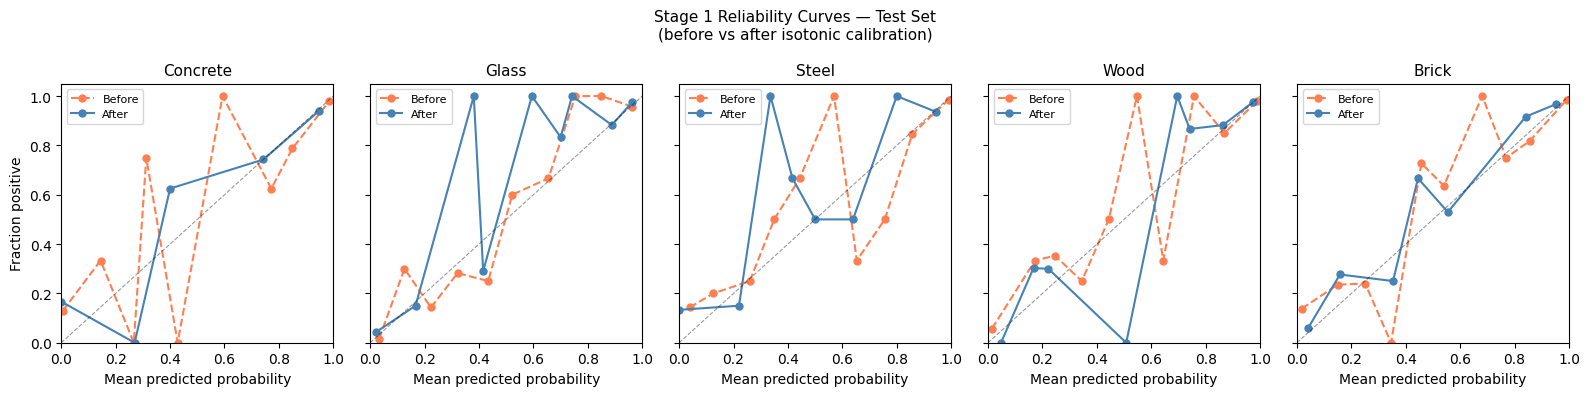

In [32]:
# ==========================================================
# Stage 1 — Probability calibration (isotonic regression)
# ==========================================================
# Evaluates reliability before calibration (test set),
# fits calibrators on the validation set, then re-evaluates.

y_val_presence  = data["y_val_mask"]  & (data["y_val_raw"]  > 0)
y_test_presence = data["y_test_mask"] & (data["y_test_raw"] > 0)

# ── Before calibration: test-set diagnostics ────────────────────────────────
print("=" * 60)
print("Stage 1 reliability — TEST SET  (before calibration)")
print("=" * 60)
cal_before = model.stage1.evaluate_calibration(data["X_test_proc"], y_test_presence)

# ── Fit calibrators on validation set ────────────────────────────────────────
model.calibrate_stage1(data["X_val_proc"], data["y_val_raw"], data["y_val_mask"])
print("\nCalibrators fitted on validation set (IsotonicRegression per material).")

# ── After calibration: test-set diagnostics ──────────────────────────────────
print()
print("=" * 60)
print("Stage 1 reliability — TEST SET  (after calibration)")
print("=" * 60)
cal_after = model.stage1.evaluate_calibration(data["X_test_proc"], y_test_presence)

# ── Reliability curves ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(y_cols), figsize=(16, 4), sharey=True)
for ax, mat in zip(axes, y_cols):
    pre  = cal_before.get(mat, {})
    post = cal_after.get(mat, {})
    mp_pre, fp_pre   = pre.get("mean_pred_bins"), pre.get("frac_pos_bins")
    mp_post, fp_post = post.get("mean_pred_bins"), post.get("frac_pos_bins")
    if mp_pre is not None and len(mp_pre):
        ax.plot(mp_pre, fp_pre, "o--", color="coral", lw=1.5, ms=5, label="Before")
    if mp_post is not None and len(mp_post):
        ax.plot(mp_post, fp_post, "o-", color="steelblue", lw=1.5, ms=5, label="After")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.4)
    ax.set_title(mat, fontsize=11)
    ax.set_xlabel("Mean predicted probability")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.05)
    ax.legend(fontsize=8)
    if ax is axes[0]:
        ax.set_ylabel("Fraction positive")

fig.suptitle(
    "Stage 1 Reliability Curves — Test Set\n(before vs after isotonic calibration)",
    fontsize=11,
)
plt.tight_layout()
plt.show()

In [33]:
# ==========================================================
# Gating Evaluation — MoE regime diagnostics
#
# For each material, evaluates how well the gating classifier
# recovers the GMM regime labels on held-out data.
#
# Metrics:
#   - Accuracy, confusion matrix, per-class precision/recall/F1
#   - Mean max gating confidence: mean(max P(regime | X))
#
# The "true" regime label for a held-out sample is assigned by
# applying the trained GaussianMixture to log(y_held_out).
# ==========================================================

print("=" * 60)
print("Gating evaluation — VALIDATION SET")
print("=" * 60)
model.stage2.evaluate_gating(data["X_val_proc"], data["y_val_raw"])

print("\n")
print("=" * 60)
print("Gating evaluation — TEST SET")
print("=" * 60)
model.stage2.evaluate_gating(data["X_test_proc"], data["y_test_raw"])


Gating evaluation — VALIDATION SET

Material: Concrete
  Gating accuracy : 0.823  (K=3 regimes, n=282)
  Mean max gating confidence : 0.815
  Confusion matrix (rows=true regime, cols=predicted regime):
[[191   2   9]
 [  6   5   7]
 [ 24   2  36]]
  Per-class precision / recall / F1:
              precision    recall  f1-score   support

           0       0.86      0.95      0.90       202
           1       0.56      0.28      0.37        18
           2       0.69      0.58      0.63        62

    accuracy                           0.82       282
   macro avg       0.70      0.60      0.64       282
weighted avg       0.81      0.82      0.81       282

  [Interpretation] Good gating accuracy — regime assignment is learnable
  from X. MoE gating is functioning as intended.

Material: Glass
  Gating accuracy : 0.710  (K=3 regimes, n=176)
  Mean max gating confidence : 0.776
  Confusion matrix (rows=true regime, cols=predicted regime):
[[ 20  32   1]
 [ 11 105   0]
 [  0   7   0]]
  

In [34]:
# ==========================================================
# Expert Diversity — MoE specialisation diagnostics
#
# For each material:
#   1. Regime sample counts (from training)
#   2. Target mean / std per regime in log-space (from training)
#   3. Pairwise correlation between expert predictions on held-out X
#   4. Mean |expert_i - expert_j| on held-out X
#
# Goal: check whether experts are actually specialised or
# collapsing into nearly identical predictors.
# ==========================================================

print("=" * 60)
print("Expert diversity — VALIDATION SET")
print("=" * 60)
model.stage2.evaluate_expert_diversity(data["X_val_proc"], data["y_val_raw"])

print("\n")
print("=" * 60)
print("Expert diversity — TEST SET")
print("=" * 60)
model.stage2.evaluate_expert_diversity(data["X_test_proc"], data["y_test_raw"])


Expert diversity — VALIDATION SET

Material: Concrete
  Regime sample counts (training) : {0: 1036, 1: 55, 2: 294}
  Target log-space stats per regime (training):
    Regime 0: n=1036  mean=7.380  std=0.363
    Regime 1: n=  55  mean=4.063  std=1.295
    Regime 2: n= 294  mean=6.239  std=0.378
  Pairwise correlation between expert predictions (log-space):
         Exp0  Exp1  Exp2
    Exp0  +1.000  -0.059  -0.010
    Exp1  -0.059  +1.000  -0.167
    Exp2  -0.010  -0.167  +1.000
  Mean |expert_i − expert_j| on held-out X (log-space):
    |Exp0 − Exp1| = 3.6328
    |Exp0 − Exp2| = 1.0525
    |Exp1 − Exp2| = 2.5803
  [Interpretation] Experts show meaningful diversity — regime specialisation
  is working as intended.

Material: Glass
  Regime sample counts (training) : {0: 242, 1: 609, 2: 35}
  Target log-space stats per regime (training):
    Regime 0: n= 242  mean=1.743  std=0.352
    Regime 1: n= 609  mean=0.689  std=0.359
    Regime 2: n=  35  mean=-0.882  std=0.623
  Pairwise correlat

In [35]:
# ==========================================================
# CRPS (Continuous Ranked Probability Score) — probabilistic calibration
# ==========================================================

print("=" * 60)
print("CRPS evaluation — VALIDATION SET")
print("=" * 60)
model.stage2.evaluate_crps(data["X_val_proc"], data["y_val_raw"])

print()
print("=" * 60)
print("CRPS evaluation — TEST SET")
print("=" * 60)
model.stage2.evaluate_crps(data["X_test_proc"], data["y_test_raw"])

CRPS evaluation — VALIDATION SET
  Material       n_obs   Mean CRPS (log-space)
  --------------------------------------------
  Concrete         282                  0.3245
  Glass            176                  0.3179
  Steel            344                  0.3556
  Wood             316                  0.5041
  Brick            257                  0.4505

CRPS evaluation — TEST SET
  Material       n_obs   Mean CRPS (log-space)
  --------------------------------------------
  Concrete         297                  0.3440
  Glass            193                  0.3266
  Steel            346                  0.3487


  Wood             313                  0.4778
  Brick            277                  0.3488


Calibration — VALIDATION SET
  Material       n_obs     10%   20%   30%   40%   50%   60%   70%   80%   90%
  -------------------------------------------------------------------------------------


  Concrete         282    0.12  0.25  0.41  0.56  0.65  0.72  0.81  0.87  0.91
  Glass            176    0.11  0.23  0.32  0.44  0.51  0.60  0.69  0.76  0.86
  Steel            344    0.12  0.25  0.39  0.49  0.59  0.68  0.77  0.84  0.93
  Wood             316    0.12  0.24  0.36  0.49  0.59  0.69  0.78  0.86  0.91
  Brick            257    0.12  0.29  0.39  0.49  0.58  0.67  0.76  0.83  0.90

Calibration — TEST SET
  Material       n_obs     10%   20%   30%   40%   50%   60%   70%   80%   90%
  -------------------------------------------------------------------------------------
  Concrete         297    0.16  0.29  0.39  0.51  0.60  0.70  0.80  0.88  0.92
  Glass            193    0.17  0.26  0.34  0.45  0.55  0.62  0.69  0.80  0.89
  Steel            346    0.15  0.24  0.40  0.50  0.59  0.70  0.79  0.85  0.92
  Wood             313    0.15  0.28  0.39  0.51  0.60  0.70  0.78  0.85  0.92
  Brick            277    0.12  0.22  0.36  0.49  0.58  0.69  0.77  0.87  0.94


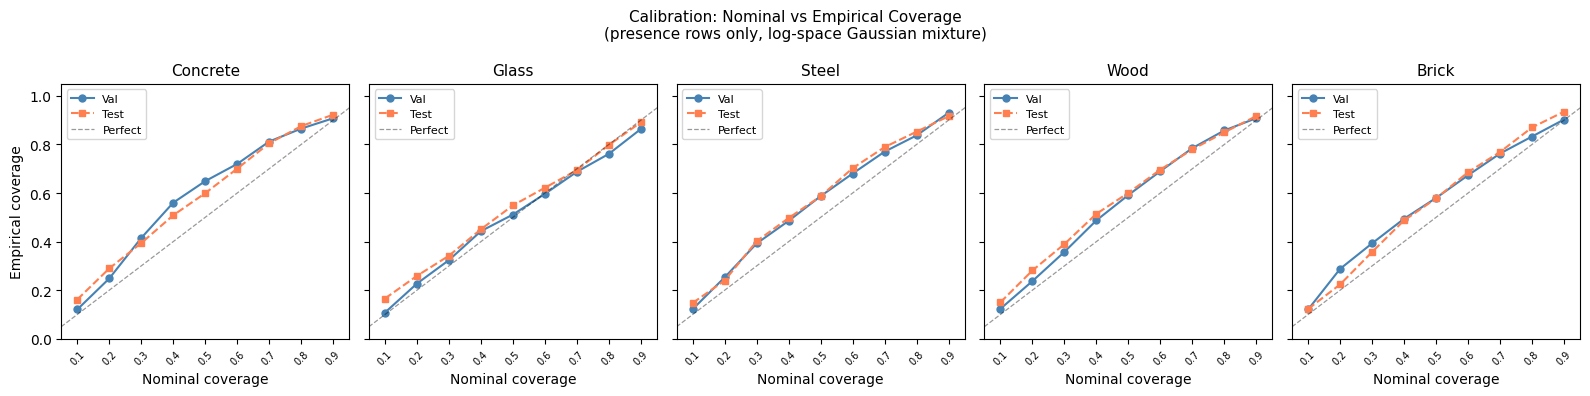

In [36]:
# ==========================================================
# Calibration — nominal vs empirical coverage (presence rows)
# ==========================================================

levels = np.linspace(0.10, 0.90, 9)

print("Calibration — VALIDATION SET")
cal_val  = model.stage2.evaluate_calibration(data["X_val_proc"],  data["y_val_raw"],  levels=levels)
print()
print("Calibration — TEST SET")
cal_test = model.stage2.evaluate_calibration(data["X_test_proc"], data["y_test_raw"], levels=levels)

fig, axes = plt.subplots(1, len(y_cols), figsize=(16, 4), sharey=True)
for ax, material in zip(axes, y_cols):
    emp_v = cal_val.get(material)
    emp_t = cal_test.get(material)
    if emp_v is not None:
        ax.plot(levels, emp_v, "o-",  color="steelblue", lw=1.5, ms=5, label="Val")
    if emp_t is not None:
        ax.plot(levels, emp_t, "s--", color="coral",     lw=1.5, ms=5, label="Test")
    ax.plot([0, 1], [0, 1], "k--", lw=0.9, alpha=0.4, label="Perfect")
    ax.set_title(material, fontsize=11)
    ax.set_xlabel("Nominal coverage")
    ax.set_xlim(0.05, 0.95)
    ax.set_ylim(0.0, 1.05)
    ax.set_xticks(levels)
    ax.tick_params(axis="x", labelsize=7, rotation=45)
    ax.legend(fontsize=8)
    if ax is axes[0]:
        ax.set_ylabel("Empirical coverage")

fig.suptitle(
    "Calibration: Nominal vs Empirical Coverage\n(presence rows only, log-space Gaussian mixture)",
    fontsize=11,
)
plt.tight_layout()
plt.show()

In [37]:
# ==========================================================
# Sampling realism diagnostics
# ==========================================================
# Evaluates 3 representative val rows: presence freq, co-occurrence,
# intensity distributions, diversity, and comparison to real buildings.

n_query   = 3
X_query   = data["X_val_proc"][:n_query]
grp_query = data["groups_val"][:n_query]

model.evaluate_sampling_realism(
    X_query, grp_query,
    y_train_raw  = data["y_train_raw"],
    y_train_mask = data["y_train_mask"],
    X_train_raw  = data["X_train_raw"],
    n_samples    = 1000,
    random_state = SEED,
)


Query row 0  |  group: B  |  n_samples=1000

A. Presence frequency per material:
   Concrete      1.000  |####################|
   Glass         0.904  |##################  |
   Steel         1.000  |####################|
   Wood          1.000  |####################|
   Brick         1.000  |####################|

B. Co-occurrence matrix  (fraction of samples):
             Concr  Glass  Steel   Wood  Brick
  Concrete      1.00  0.90  1.00  1.00  1.00
  Glass         0.90  0.90  0.90  0.90  0.90
  Steel         1.00  0.90  1.00  1.00  1.00
  Wood          1.00  0.90  1.00  1.00  1.00
  Brick         1.00  0.90  1.00  1.00  1.00

C. Sampled intensity distribution  (kg/m², presence rows only):
   Material      n_pres      mean    median        p5       p95
   ----------------------------------------------------------
   Concrete        1000    1906.0    1723.5     528.7    3899.0
   Glass            904       3.7       2.8       0.5      10.5
   Steel           1000      26.3      17.7

In [38]:
# ==========================================================
# Automatic Hyperparameter Tuning Workflow (Optuna)
# ==========================================================
def compute_naive_maes(y_train_raw, y_train_mask):
    # MAE of per-material training-mean naive forecast — denominator for MASE.
    # Presence rows only: the conditional regressor is trained on y > 0,
    # so the naive baseline must be computed on the same support.
    naive_maes = {}
    for m, mat in enumerate(y_cols):
        obs = y_train_mask[:, m] & (y_train_raw[:, m] > 0)
        if obs.sum() > 0:
            vals = y_train_raw[obs, m]
            naive_maes[mat] = float(np.mean(np.abs(vals - vals.mean())))
    return naive_maes


def compute_mase(pred_dict, y_df, naive_maes, eps=1e-8):
    # MASE averaged across materials, evaluated on presence rows only.
    # Evaluating Stage 2 (conditional intensity) against y=0 rows would
    # penalise it for a job that belongs to Stage 1 (presence classification).
    mases = []
    for mat in y_cols:
        y_true = y_df[mat].to_numpy(dtype=float)
        obs = (~np.isnan(y_true)) & (y_true > 0)
        if np.any(obs):
            y_pred = pred_dict[mat]["p50"][obs]
            mae = np.mean(np.abs(y_pred - y_true[obs]))
            mases.append(mae / (naive_maes.get(mat, 1.0) + eps))
    return float(np.mean(mases)) if mases else np.inf


naive_maes = compute_naive_maes(data["y_train_raw"], data["y_train_mask"])

def objective(trial):
    n_estimators     = trial.suggest_int("n_estimators", 100, 600)
    max_depth        = trial.suggest_int("max_depth", 3, 7)
    learning_rate    = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
    subsample        = trial.suggest_float("subsample", 0.6, 1.0)
    colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0)
    reg_alpha        = trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True)
    reg_lambda       = trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True)
    cov_shrink       = trial.suggest_float("cov_shrink", 0.0, 1.0)
    min_group_size   = trial.suggest_int("min_group_size", 10, 40)
    reg_eps          = trial.suggest_float("reg_eps", 1e-6, 1e-2, log=True)

    tuned_model = TwoStageConditionalModel(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        cov_shrink=cov_shrink,
        min_group_size=min_group_size,
        reg_eps=reg_eps,
        random_state=SEED,
    )
    tuned_model.fit(
        data["X_train_proc"],
        data["X_train_raw"],
        data["y_train_raw"],
        data["y_train_mask"],
    )
    preds_val = tuned_model.predict(data["X_val_proc"], data["groups_val"], alpha=0.10)
    return compute_mase(preds_val, data["y_val_df"], naive_maes)

set_global_seed(SEED)
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=50, show_progress_bar=False)

print("Best validation MASE:", round(study.best_value, 6))
print("Best params:", study.best_params)

best = study.best_params
model = TwoStageConditionalModel(
    n_estimators=best["n_estimators"],
    max_depth=best["max_depth"],
    learning_rate=best["learning_rate"],
    subsample=best["subsample"],
    colsample_bytree=best["colsample_bytree"],
    reg_alpha=best["reg_alpha"],
    reg_lambda=best["reg_lambda"],
    cov_shrink=best["cov_shrink"],
    min_group_size=best["min_group_size"],
    reg_eps=best["reg_eps"],
    random_state=SEED,
)
model.fit(
    data["X_train_proc"],
    data["X_train_raw"],
    data["y_train_raw"],
    data["y_train_mask"],
)
print("Tuned model fitted and assigned to variable: model")

[I 2026-05-09 13:35:44,388] A new study created in memory with name: no-name-29425a40-bec5-4420-af44-0d9c546ecb8b
[I 2026-05-09 13:36:11,995] Trial 0 finished with value: 0.6607667719887982 and parameters: {'n_estimators': 287, 'max_depth': 7, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_alpha': 2.5348407664333426e-07, 'reg_lambda': 3.3323645788192616e-08, 'cov_shrink': 0.8661761457749352, 'min_group_size': 28, 'reg_eps': 0.0006796578090758161}. Best is trial 0 with value: 0.6607667719887982.
[I 2026-05-09 13:36:24,718] Trial 1 finished with value: 0.6553340385242153 and parameters: {'n_estimators': 110, 'max_depth': 7, 'learning_rate': 0.16967533607196555, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.6727299868828402, 'reg_alpha': 4.4734294104626844e-07, 'reg_lambda': 5.472429642032198e-06, 'cov_shrink': 0.5247564316322378, 'min_group_size': 23, 'reg_eps': 1.461896279370496e-05}. Best is trial 1 with value

Best validation MASE: 0.644577
Best params: {'n_estimators': 399, 'max_depth': 5, 'learning_rate': 0.030043607123456318, 'subsample': 0.8510403897109361, 'colsample_bytree': 0.6208008415832331, 'reg_alpha': 3.1684211040592003e-06, 'reg_lambda': 1.3234394712132709e-06, 'cov_shrink': 0.31782094029455393, 'min_group_size': 35, 'reg_eps': 1.29152444915273e-05}
Tuned model fitted and assigned to variable: model


In [39]:
# ==========================================================
# Prediction on test set
# ==========================================================

pred_test = model.predict(data["X_test_proc"], data["groups_test"], alpha=0.10)

print("Sample predictions (first 3 test buildings):\n")
for mat in y_cols:
    p = pred_test[mat]
    print(
        f"{mat:<10s}  "
        f"p_presence={np.round(p['p_presence'][:3], 2)}  "
        f"p50={np.round(p['p50'][:3], 1)}  "
        f"90%PI=[{np.round(p['p5'][:3], 1)}, {np.round(p['p95'][:3], 1)}]"
    )


Sample predictions (first 3 test buildings):

Concrete    p_presence=[0.   1.   0.78]  p50=[ 887.  1333.2  764.3]  90%PI=[[178.2 651.2 257.1], [4414.5 2729.3 2272.2]]
Glass       p_presence=[0.98 0.97 0.25]  p50=[2.9 1.7 1.1]  90%PI=[[1.3 0.9 0.6], [6.4 3.  2. ]]
Steel       p_presence=[1.   1.   0.84]  p50=[20.5 23.8 13.4]  90%PI=[[8.3 7.1 3.5], [50.2 80.2 52. ]]
Wood        p_presence=[0.99 0.99 0.99]  p50=[16.3  9.3 12.9]  90%PI=[[3.1 1.7 1.2], [ 86.5  49.9 138.3]]
Brick       p_presence=[1.   0.99 0.99]  p50=[123.1 105.1 332.1]  90%PI=[[30.6 16.2 63.5], [ 495.2  682.6 1736. ]]


Model Assessment

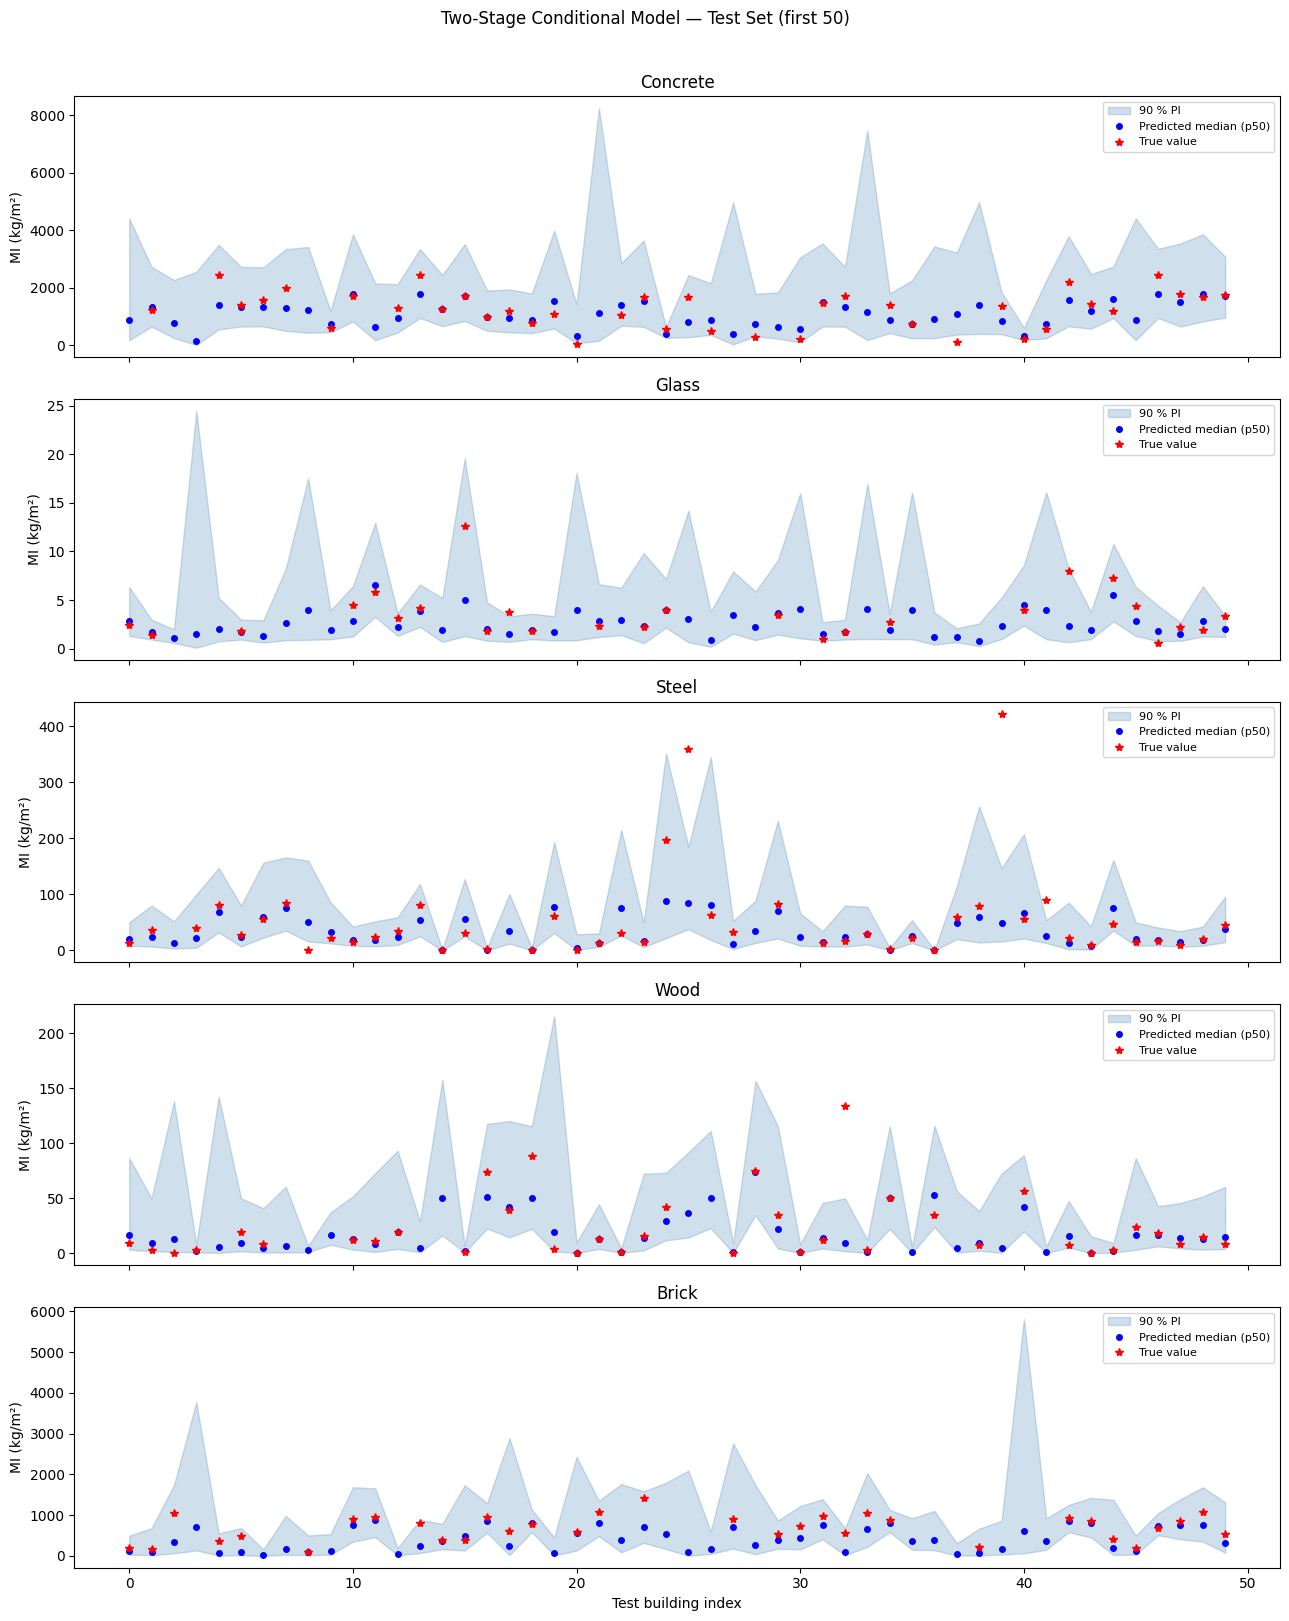

In [40]:
# ==========================================================
# Visualisation — predicted median + 90 % PI vs. true values
#                 (first 50 test-set buildings)
# ==========================================================

n_plot = 50
pred_plot = model.predict(data["X_test_proc"][:n_plot], data["groups_test"][:n_plot], alpha=0.10)

fig, axes = plt.subplots(5, 1, figsize=(13, 16), sharex=True)
x_idx = np.arange(n_plot)

for i, mat in enumerate(y_cols):
    ax = axes[i]
    y_true = data["y_test_df"][mat].iloc[:n_plot].to_numpy(dtype=float)
    observed = ~np.isnan(y_true)
    y_true_plot = y_true.copy()
    y_true_plot[~observed] = np.nan

    ax.fill_between(x_idx, pred_plot[mat]["p5"], pred_plot[mat]["p95"],
                    alpha=0.25, color="steelblue", label="90 % PI")
    ax.plot(x_idx, pred_plot[mat]["p50"], "bo", ms=4, label="Predicted median (p50)")
    ax.plot(x_idx, y_true_plot, "r*", ms=6, label="True value")
    ax.set_title(mat)
    ax.set_ylabel("MI (kg/m\u00b2)")
    ax.legend(fontsize=8)

axes[-1].set_xlabel("Test building index")
plt.suptitle("Two-Stage Conditional Model \u2014 Test Set (first 50)", y=1.01)
plt.tight_layout()
plt.show()


Presence-complete test rows: 135
  mean_vector_mae: 48.95
  cov_frobenius: 2.4903e+05
  corr_frobenius: 1.2937
  kl_true_to_pred: 17.262
  kl_pred_to_true: 2.349


,material,true_mean,pred_mean,abs_mean_diff,true_std,pred_std,abs_std_diff
0,Concrete,1654.170734,1508.060088,146.110646,636.373380,403.099224,233.274156
1,Glass,2.922884,2.564972,0.357912,2.349873,1.188669,1.161204
2,Steel,25.643327,22.810151,2.833176,38.475675,15.812850,22.662825
3,Wood,23.603882,19.284286,4.319596,23.055424,15.162594,7.892830
4,Brick,682.684163,591.553017,91.131146,300.128005,249.156532,50.971474


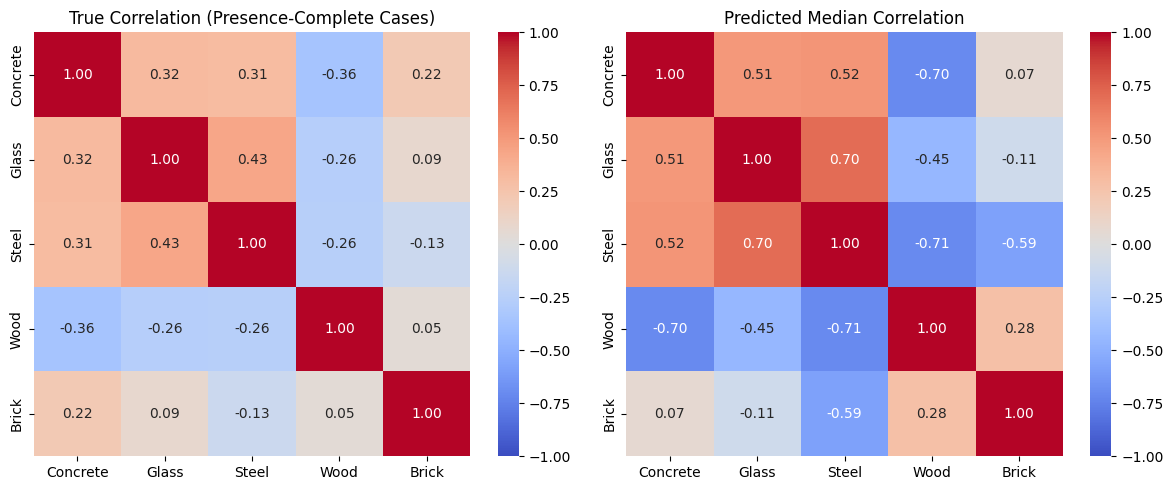

In [41]:
# ==========================================================
# Joint distribution evaluation
#   - Marginal moments (presence-complete rows)
#   - Material correlation heatmaps (true vs. predicted)
# ==========================================================

def _gaussian_kl(mu_p, cov_p, mu_q, cov_q, eps=1e-6):
    d = mu_p.shape[0]
    cov_p_r = cov_p + np.eye(d) * eps
    cov_q_r = cov_q + np.eye(d) * eps
    sp, ldp = np.linalg.slogdet(cov_p_r)
    sq, ldq = np.linalg.slogdet(cov_q_r)
    if sp <= 0 or sq <= 0:
        return np.nan
    inv_q = np.linalg.inv(cov_q_r)
    return 0.5 * (np.trace(inv_q @ cov_p_r)
                  + (mu_q - mu_p) @ inv_q @ (mu_q - mu_p)
                  - d + (ldq - ldp))


# Presence-complete rows: all 5 materials observed AND > 0.
# Matches the support used by JointDistributionModel.fit(); using y_mask.all()
# would include observed-as-zero rows whose covariance is not well-defined.
cc = (~np.isnan(data["y_test_raw"]) & (data["y_test_raw"] > 0)).all(axis=1)
y_tc = data["y_test_raw"][cc]
y_pc = model.stage2.predict(data["X_test_proc"][cc])

mu_t, mu_p   = y_tc.mean(0), y_pc.mean(0)
std_t, std_p = y_tc.std(0, ddof=1), y_pc.std(0, ddof=1)
cov_t  = np.cov(y_tc, rowvar=False)
cov_p  = np.cov(y_pc, rowvar=False)
corr_t = np.corrcoef(y_tc, rowvar=False)
corr_p = np.corrcoef(y_pc, rowvar=False)

print(f"Presence-complete test rows: {cc.sum()}")
stats_summary = {
    "mean_vector_mae":  float(np.mean(np.abs(mu_t - mu_p))),
    "cov_frobenius":    float(np.linalg.norm(cov_t - cov_p, ord="fro")),
    "corr_frobenius":   float(np.linalg.norm(corr_t - corr_p, ord="fro")),
    "kl_true_to_pred":  float(_gaussian_kl(mu_t, cov_t, mu_p, cov_p)),
    "kl_pred_to_true":  float(_gaussian_kl(mu_p, cov_p, mu_t, cov_t)),
}
for k, v in stats_summary.items():
    print(f"  {k}: {v:.5g}")

per_material = pd.DataFrame({
    "material": y_cols,
    "true_mean": mu_t, "pred_mean": mu_p, "abs_mean_diff": np.abs(mu_t - mu_p),
    "true_std":  std_t, "pred_std":  std_p, "abs_std_diff":  np.abs(std_t - std_p),
})
display(per_material)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, corr, title in zip(axes, [corr_t, corr_p],
                            ["True Correlation (Presence-Complete Cases)", "Predicted Median Correlation"]):
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
                xticklabels=y_cols, yticklabels=y_cols, ax=ax)
    ax.set_title(title)
plt.tight_layout()
plt.show()


In [42]:
# ==========================================================
# Save artefacts
# ==========================================================

# Rebind classes to the importable module path before pickling.
# This prevents __main__-scoped notebook classes from breaking joblib.load elsewhere.

model.__class__        = tsm.TwoStageConditionalModel
model.stage1.__class__ = tsm.MaterialOccurrenceModel
model.stage2.__class__ = tsm.MaterialIntensityModel
model.joint.__class__  = tsm.JointDistributionModel

for mat in y_cols:
    moe = model.stage2.models_.get(mat)
    if moe is not None:
        moe.__class__ = tsm._PerMaterialMoE

joblib.dump(data["preprocessor"], "preprocessor.joblib")
joblib.dump(model, "model.joblib")

model_info = {
    "model_type":  "TwoStageConditionalModel",
    "stage1":      "XGBClassifier per-material (binary:logistic)",
    "stage2":      "MoE: GaussianMixture regime labels + XGBClassifier gating + XGBRegressor experts (log-space)",
    "stage2_n_components": model.stage2.n_components,
    "stage2_regime_counts": {
        mat: (model.stage2.models_[mat].K_
              if model.stage2.models_.get(mat) is not None else 0)
        for mat in y_cols
    },
    "joint_layer": "MultivariateNormal with group-specific covariance (residual inspection only)",
    "group_cols":  list(GROUP_COLS),
    "y_cols":      y_cols,
    "X_cols":      X_cols,
    "stage1_xgb_params": model.stage1.xgb_params,
    "stage2_xgb_params": model.stage2.xgb_params,
}
with open("model_info.json", "w", encoding="utf-8") as f:
    json.dump(model_info, f, indent=2)

print("Saved: preprocessor.joblib,  model.joblib,  model_info.json")


Saved: preprocessor.joblib,  model.joblib,  model_info.json


In [43]:
# ==========================================================
# Validation 1 — Coverage, Interval Width, Median MAE
#   Evaluated on presence rows only (observed AND y > 0).
#   Coverage/MAE of the conditional intensity model against y=0 rows
#   is incoherent: those rows are Stage 1's responsibility.
# ==========================================================

coverage_results = []
for mat in y_cols:
    y_true = data["y_test_df"][mat].to_numpy(dtype=float)
    obs    = (~np.isnan(y_true)) & (y_true > 0)
    y_true = y_true[obs]
    q05 = pred_test[mat]["p5"][obs]
    q50 = pred_test[mat]["p50"][obs]
    q95 = pred_test[mat]["p95"][obs]
    widths = q95 - q05
    coverage_results.append({
        "material":     mat,
        "coverage_90":  round(float(np.mean((y_true >= q05) & (y_true <= q95))), 4),
        "mean_width":   round(float(widths.mean()), 2),
        "median_width": round(float(np.median(widths)), 2),
        "p50_mae":      round(mean_absolute_error(y_true, q50), 4),
    })

coverage_df = pd.DataFrame(coverage_results)
print("===== Coverage / Width / p50 MAE  (presence rows) =====")
print(coverage_df.to_string(index=False))


===== Coverage / Width / p50 MAE  (presence rows) =====
material  coverage_90  mean_width  median_width  p50_mae
Concrete       0.9125     3119.58       2406.02 462.4337
   Glass       0.8705        5.15          5.17   1.1717
   Steel       0.9277       91.95         73.14  18.8527
    Wood       0.8978       52.72         41.38   9.3341
   Brick       0.9242     1230.37       1016.73 218.9928


In [44]:
# ==========================================================
# Validation 5 — Baseline Comparison (training-set median)
#   Both model MAE and baseline MAE restricted to presence rows,
#   matching the support of the conditional Stage 2 regressor.
# ==========================================================

baseline_results = []
for i, mat in enumerate(y_cols):
    tr = data["y_train_raw"][:, i]
    # Presence-only baseline: median of positive training values
    tr = tr[(~np.isnan(tr)) & (tr > 0)]
    train_median = float(np.median(tr)) if len(tr) > 0 else 0.0

    y_true = data["y_test_df"][mat].to_numpy(dtype=float)
    obs    = (~np.isnan(y_true)) & (y_true > 0)
    y_true = y_true[obs]

    b_mae = mean_absolute_error(y_true, np.full_like(y_true, train_median))
    m_mae = coverage_df.loc[coverage_df["material"] == mat, "p50_mae"].values[0]

    baseline_results.append({
        "Material":        mat,
        "Baseline MAE":    round(b_mae, 2),
        "Model MAE":       round(float(m_mae), 2),
        "Improvement (%)": round((b_mae - m_mae) / b_mae * 100, 1) if b_mae > 0 else float("nan"),
    })

print("===== Baseline Comparison  (presence rows) =====")
print(pd.DataFrame(baseline_results).to_string(index=False))


===== Baseline Comparison  (presence rows) =====
Material  Baseline MAE  Model MAE  Improvement (%)
Concrete        662.18     462.43             30.2
   Glass          1.42       1.17             17.5
   Steel         30.40      18.85             38.0
    Wood         17.62       9.33             47.0
   Brick        301.84     218.99             27.4
